In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATASET INITIALIZATION ---
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Data Preprocessing & Feature Engineering
df = df.drop_duplicates()
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

sns.set_theme(style="whitegrid", palette="muted")

**Graph 1: Multi-Panel Distribution Grid**

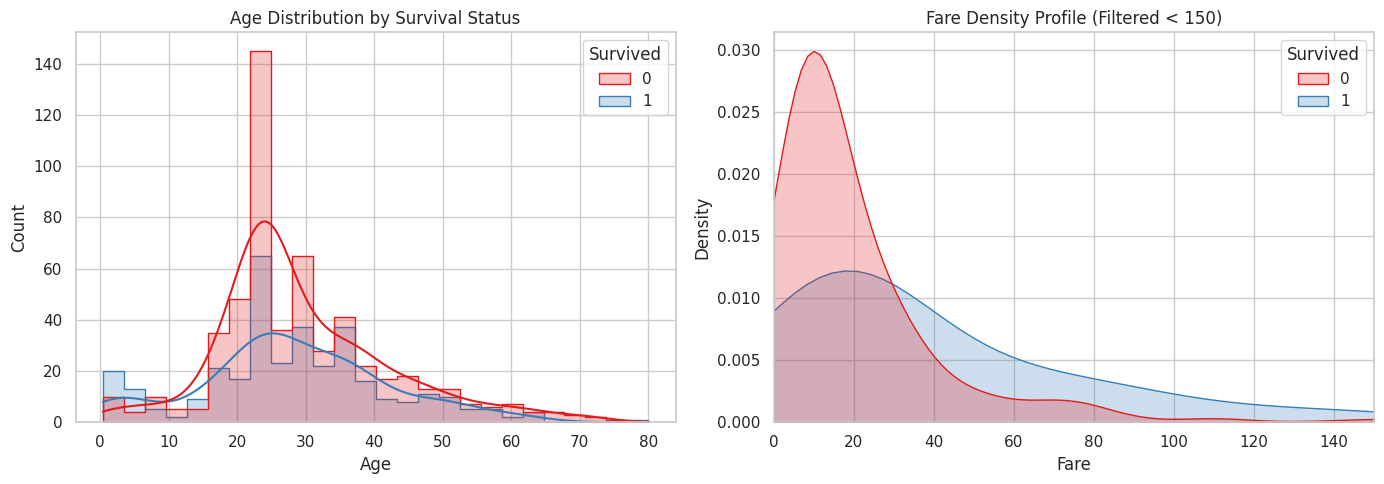

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Age Distribution
sns.histplot(df, x='Age', hue='Survived', kde=True, element='step', ax=axes[0], palette='Set1')
axes[0].set_title('Age Distribution by Survival Status')

# Subplot 2: Fare Density Profile
sns.kdeplot(data=df, x='Fare', hue='Survived', common_norm=False, fill=True, ax=axes[1], palette='Set1')
axes[1].set_xlim(0, 150)
axes[1].set_title('Fare Density Profile (Filtered < 150)')

plt.tight_layout()
plt.savefig('vis1_distribution.png', dpi=300)
plt.show()  # Displays graph directly in Colab output

**Graph 2: Class & Gender Survival Rate Matrix**

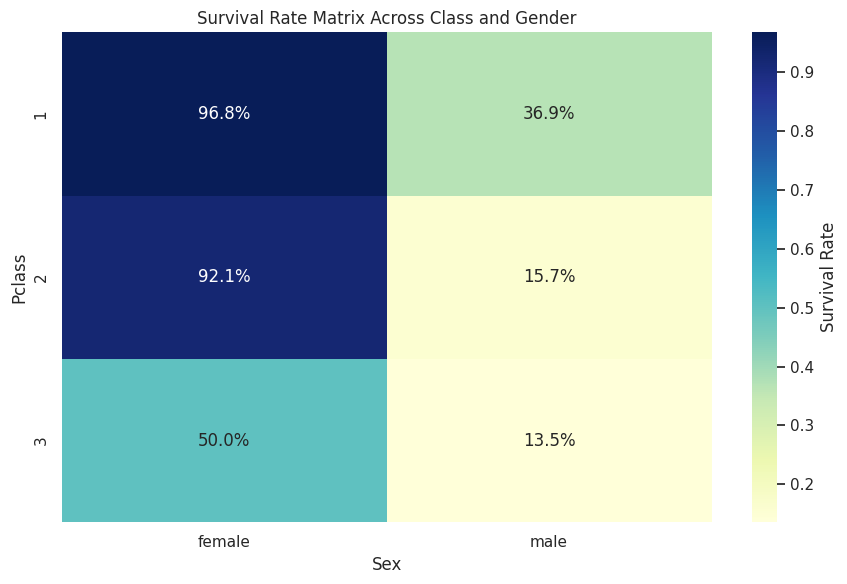

In [ ]:
plt.figure(figsize=(9, 6))
pivot_table = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap='YlGnBu', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate Matrix Across Class and Gender')

plt.tight_layout()
plt.savefig('vis2_heatmap.png', dpi=300)
plt.show()  # Displays graph directly in Colab output

**Graph 3: Faceted Embarkation, Class, and Gender Analysis**

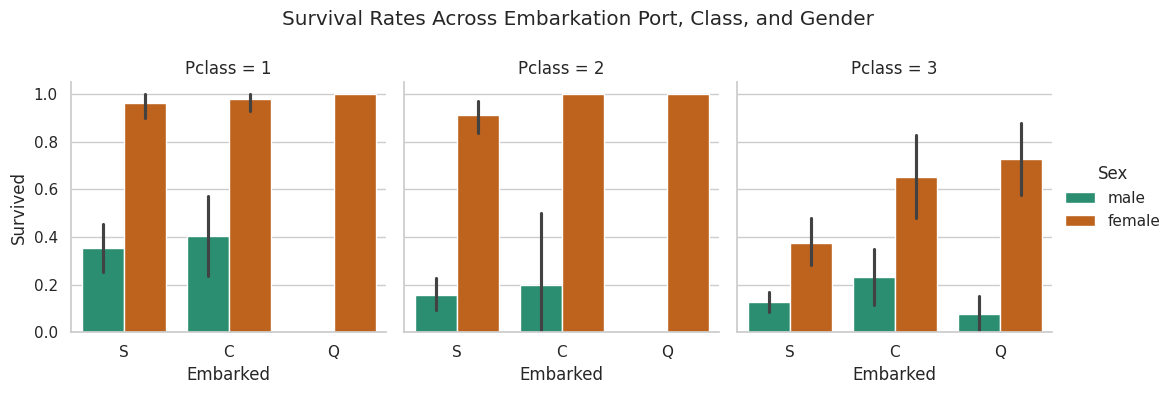

In [ ]:
g = sns.catplot(
    data=df, x='Embarked', y='Survived', hue='Sex', col='Pclass',
    kind='bar', palette='Dark2', height=4, aspect=0.9
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Survival Rates Across Embarkation Port, Class, and Gender')

plt.savefig('vis3_facet.png', dpi=300)
plt.show()  # Displays graph directly in Colab output

**Graph 4: Family Size vs. Age Boxplot Stratification**

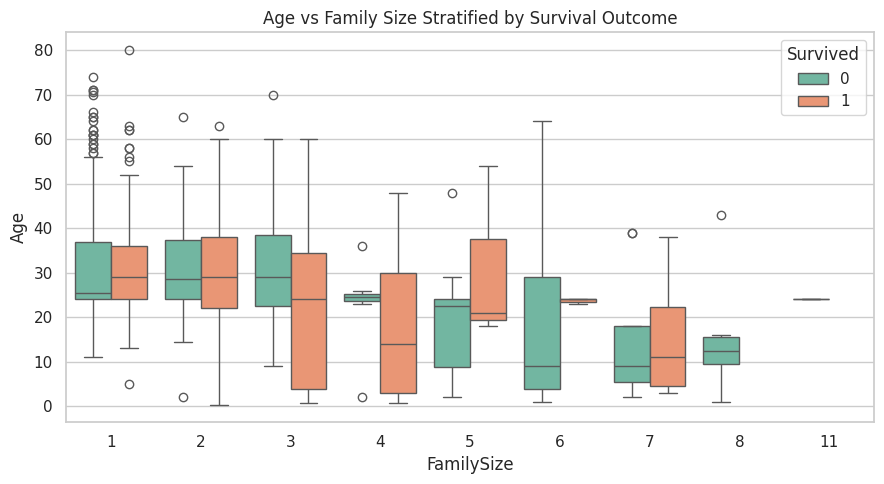

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='FamilySize', y='Age', hue='Survived', data=df, palette='Set2')
plt.title('Age vs Family Size Stratified by Survival Outcome')

plt.tight_layout()
plt.savefig('vis4_family_box.png', dpi=300)
plt.show()  # Displays graph directly in Colab output

**Graph 5: Full Correlation Matrix Heatmap**

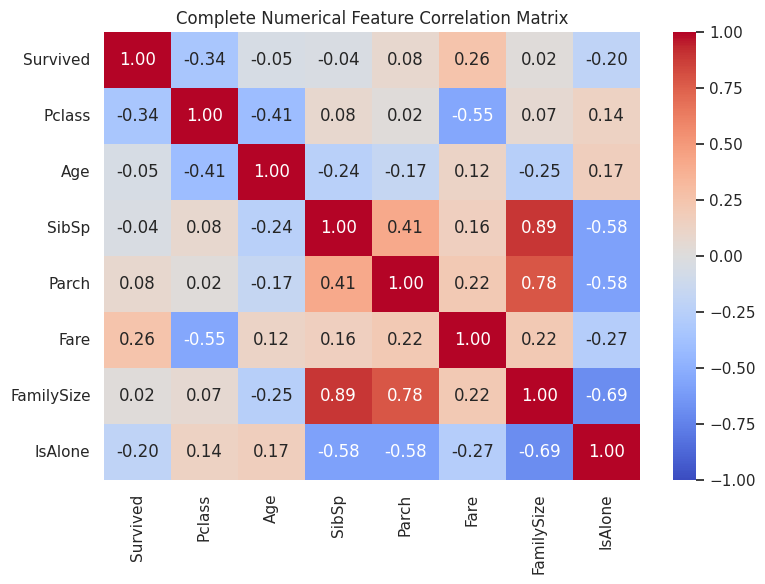

In [ ]:
plt.figure(figsize=(8, 6))
num_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']]

sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Complete Numerical Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('vis5_correlation.png', dpi=300)
plt.show()  # Displays graph directly in Colab output